## **16. 특징 선택**

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime
from matplotlib import pyplot as plt
import seaborn as sns

In [2]:
# 타임스탬프 파싱 함수

def parser(x):
    return datetime.strptime(x, '%Y-%m-%d %H:%M:%S')


In [4]:
# 데이터셋 로딩

path = './'
file = 'AirQualityUCI_refined.csv'

df = pd.read_csv(
    path + file,
    index_col=[0],
    parse_dates=[0],
    date_format='%Y-%m-%d %H:%M:%S'
)

df.head()

,CO(GT),PT08.S1(CO),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),RH,AH,C6H6(GT)
Datetime,,,,,,,,,,,
2004-03-10 18:00:00,2.6,1360.0,1046.0,166.0,1056.0,113.0,1692.0,1268.0,48.9,0.7578,11.9
2004-03-10 19:00:00,2.0,1292.0,955.0,103.0,1174.0,92.0,1559.0,972.0,47.7,0.7255,9.4
2004-03-10 20:00:00,2.2,1402.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,54.0,0.7502,9.0
2004-03-10 21:00:00,2.2,1376.0,948.0,172.0,1092.0,122.0,1584.0,1203.0,60.0,0.7867,9.2
2004-03-10 22:00:00,1.6,1272.0,836.0,131.0,1205.0,116.0,1490.0,1110.0,59.6,0.7888,6.5


In [7]:
# # 시각화 설정 옵션 (qt5 설치된 환경에서만 실행)
%matplotlib qt5
%config InlineBackend.figure_format = 'svg'

plt.rcParams['figure.figsize'] = [12, 5]
plt.rcParams['font.size'] = 13
plt.ion()

In [5]:
# [+] 전체 변수에 대한 결측치 처리 (선형 보간)
df.interpolate(inplace=True)
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 9357 entries, 2004-03-10 18:00:00 to 2005-04-04 14:00:00
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CO(GT)         9357 non-null   float64
 1   PT08.S1(CO)    9357 non-null   float64
 2   PT08.S2(NMHC)  9357 non-null   float64
 3   NOx(GT)        9357 non-null   float64
 4   PT08.S3(NOx)   9357 non-null   float64
 5   NO2(GT)        9357 non-null   float64
 6   PT08.S4(NO2)   9357 non-null   float64
 7   PT08.S5(O3)    9357 non-null   float64
 8   RH             9357 non-null   float64
 9   AH             9357 non-null   float64
 10  C6H6(GT)       9357 non-null   float64
dtypes: float64(11)
memory usage: 877.2 KB


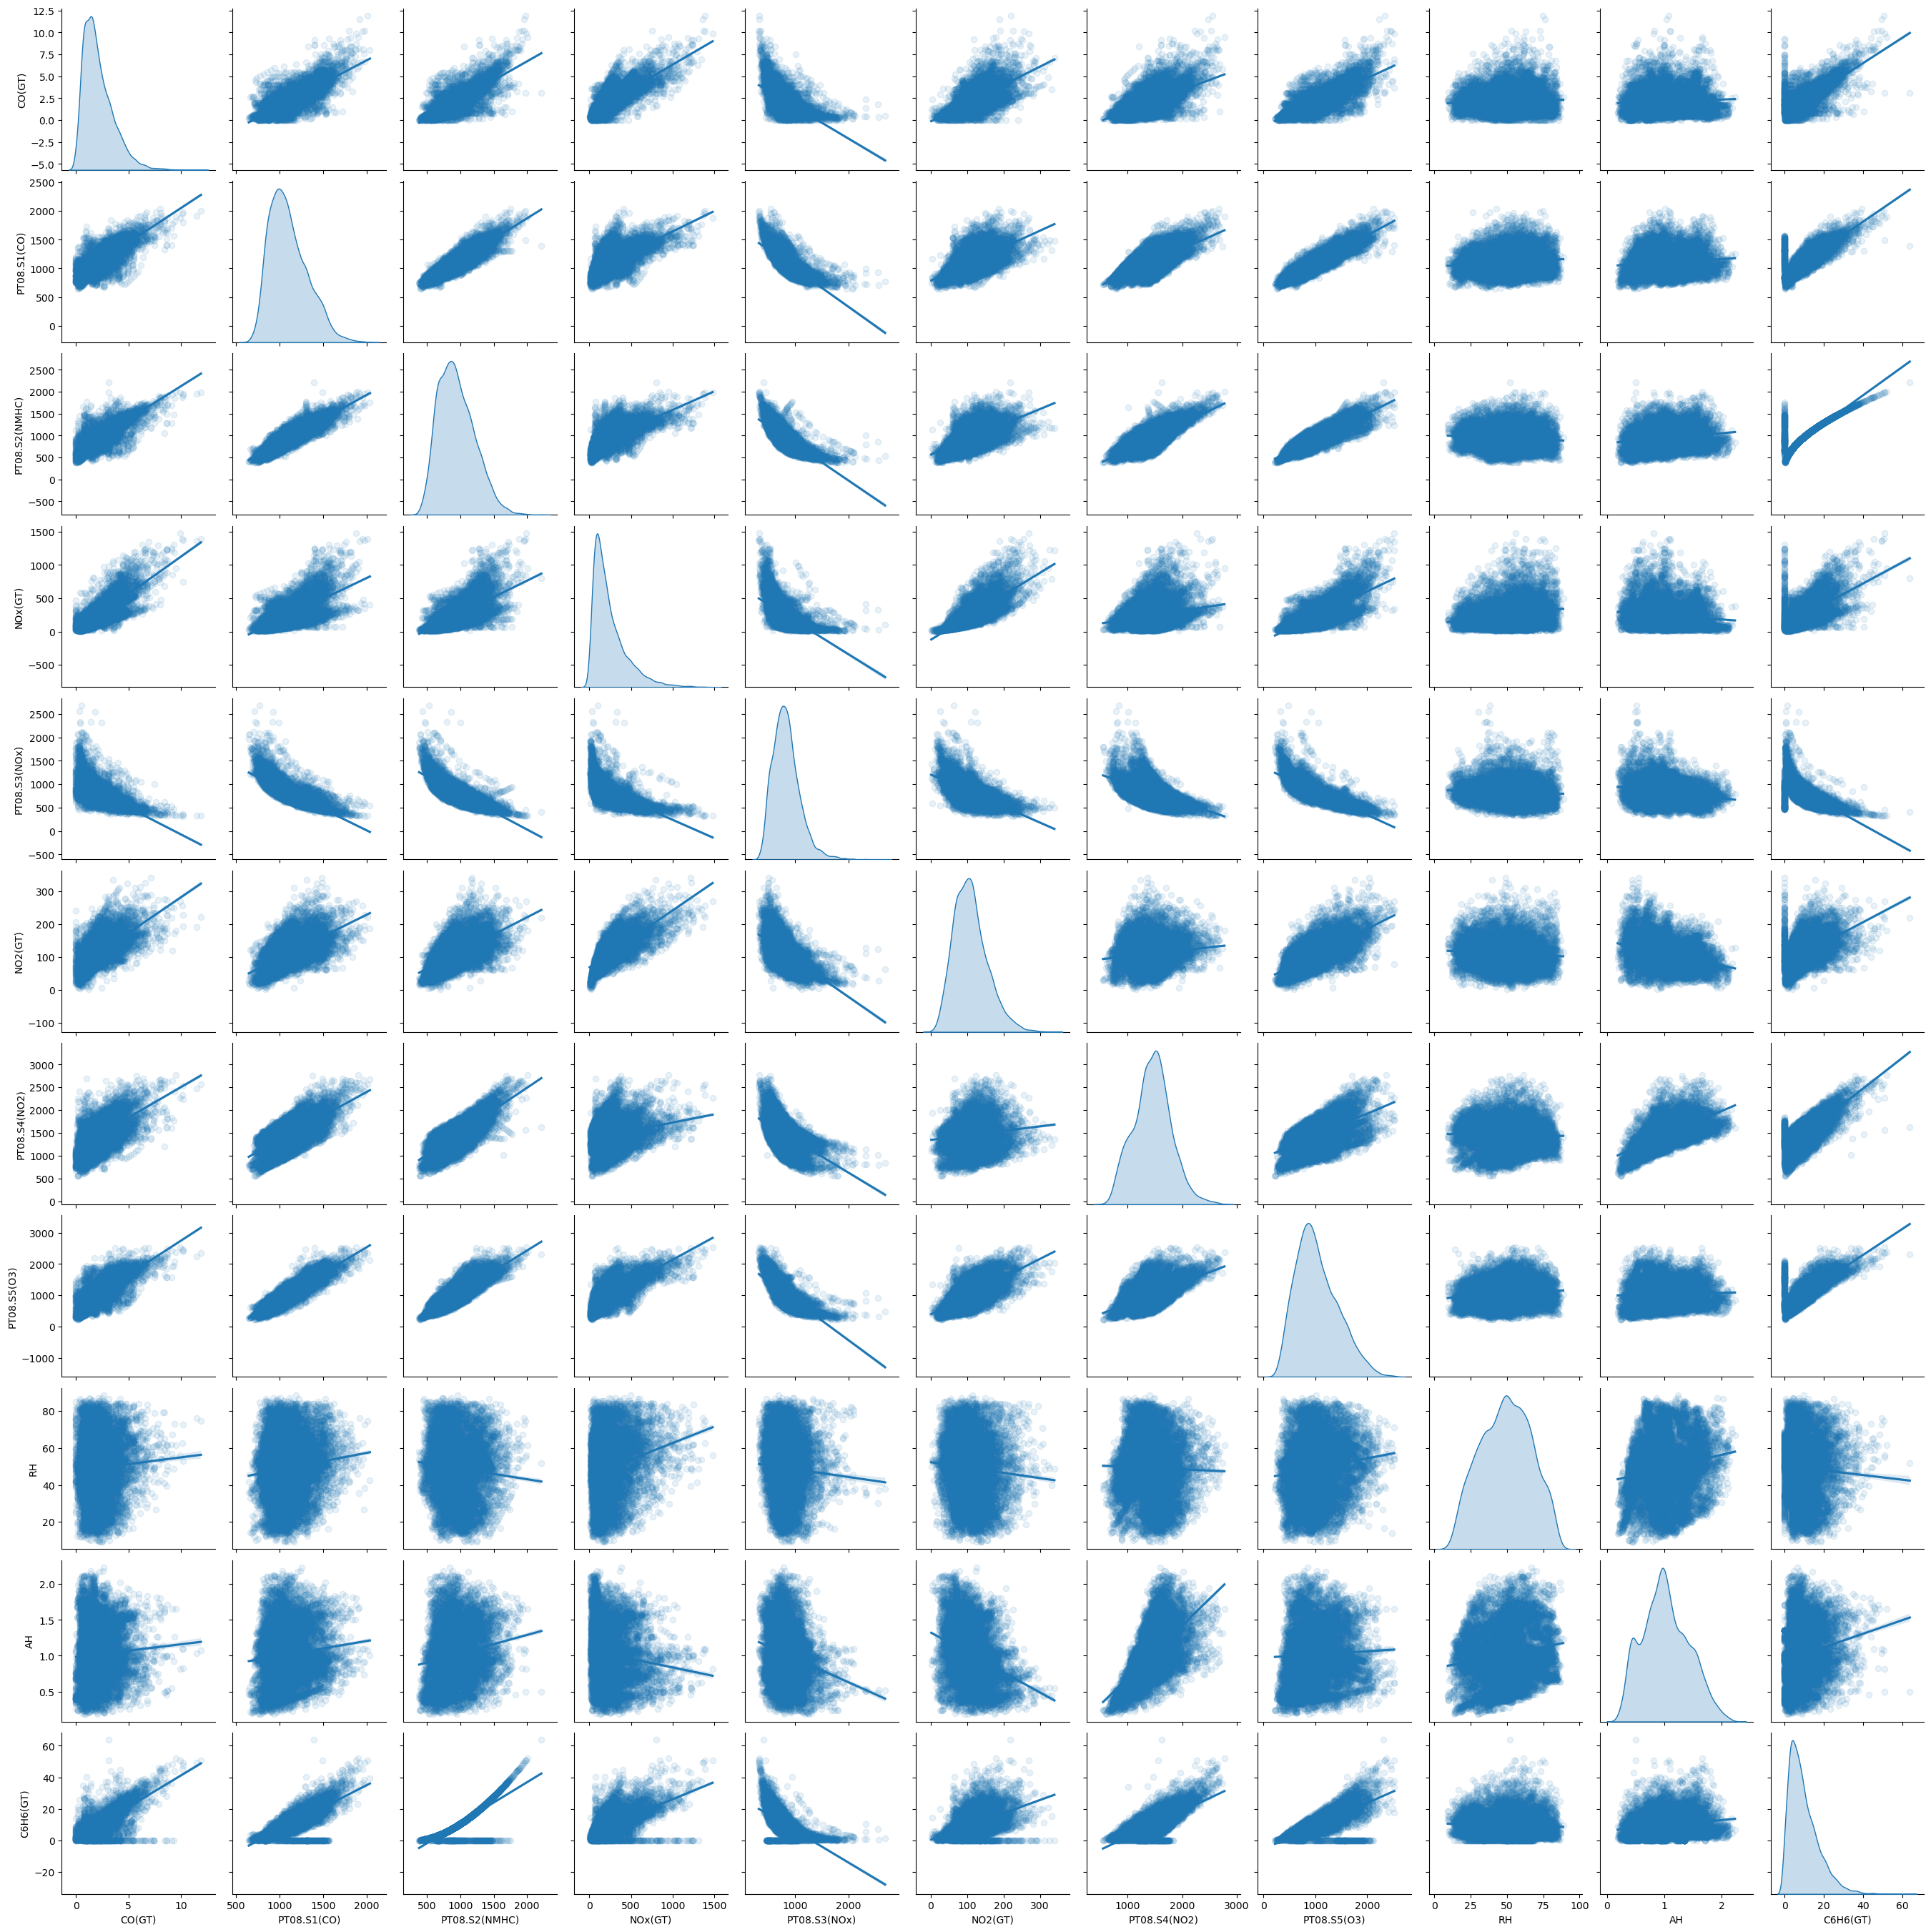

In [6]:
# 상관행렬 시각화
sns.pairplot(
    df, 
    kind='reg', 
    diag_kind='kde', 
    plot_kws={'scatter_kws': {'alpha': 0.1}}
)

In [8]:
# [+] 상관계수 측정
df.corr()

,CO(GT),PT08.S1(CO),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),RH,AH,C6H6(GT)
CO(GT),1.000000,0.793021,0.807142,0.789544,-0.647024,0.673540,0.558919,0.773442,0.061133,0.063548,0.761713
PT08.S1(CO),0.793021,1.000000,0.892045,0.667099,-0.777083,0.617714,0.667361,0.901731,0.115498,0.112241,0.813633
PT08.S2(NMHC),0.807142,0.892045,1.000000,0.646925,-0.793180,0.601650,0.765290,0.875130,-0.089798,0.170344,0.911915
NOx(GT),0.789544,0.667099,0.646925,1.000000,-0.626814,0.763038,0.214655,0.735982,0.212168,-0.122630,0.587481
PT08.S3(NOx),-0.647024,-0.777083,-0.793180,-0.626814,1.000000,-0.622142,-0.528604,-0.798375,-0.062422,-0.212475,-0.685988
NO2(GT),0.673540,0.617714,0.601650,0.763038,-0.622142,1.000000,0.134203,0.679754,-0.077801,-0.322243,0.514042
PT08.S4(NO2),0.558919,0.667361,0.765290,0.214655,-0.528604,0.134203,1.000000,0.569545,-0.026601,0.629481,0.742489
PT08.S5(O3),0.773442,0.901731,0.875130,0.735982,-0.798375,0.679754,0.569545,1.000000,0.127247,0.044611,0.777093
RH,0.061133,0.115498,-0.089798,0.212168,-0.062422,-0.077801,-0.026601,0.127247,1.000000,0.170529,-0.055630
AH,0.063548,0.112241,0.170344,-0.122630,-0.212475,-0.322243,0.629481,0.044611,0.170529,1.000000,0.178522


**모델 학습 및 특징 중요도 출력**

특징 집합을 훈련 데이터로 학습하여 일산화탄소를 예측하는 회귀 모델
- 레이블: 일산화탄소(`CO(GT)`)
- 특징 집합: `CO(GT)`를 제외한 나머지 변수

In [9]:
df.head()

,CO(GT),PT08.S1(CO),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),RH,AH,C6H6(GT)
Datetime,,,,,,,,,,,
2004-03-10 18:00:00,2.6,1360.0,1046.0,166.0,1056.0,113.0,1692.0,1268.0,48.9,0.7578,11.9
2004-03-10 19:00:00,2.0,1292.0,955.0,103.0,1174.0,92.0,1559.0,972.0,47.7,0.7255,9.4
2004-03-10 20:00:00,2.2,1402.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,54.0,0.7502,9.0
2004-03-10 21:00:00,2.2,1376.0,948.0,172.0,1092.0,122.0,1584.0,1203.0,60.0,0.7867,9.2
2004-03-10 22:00:00,1.6,1272.0,836.0,131.0,1205.0,116.0,1490.0,1110.0,59.6,0.7888,6.5


In [11]:
# [+] 학습 데이터셋 준비
X = df.iloc[:, 1:]  # 훈련 데이터
y = df.iloc[:, 0]# 레이블 데이터
print(X.shape, y.shape)

(9357, 10) (9357,)


In [16]:
from sklearn.model_selection import train_test_split

# [+] 훈련 / 테스트 분할
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=1
)

In [17]:
from sklearn.ensemble import RandomForestRegressor  # 랜덤 포레스트 회귀 모형

model = RandomForestRegressor()# [+] 모델 객체 생성
model.fit(X_train, y_train)# [+] 모델 학습

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [18]:
# [+] 예측 수행
y_pred = model.predict(X_test)

In [19]:
from sklearn.metrics import mean_absolute_error

# [+] MAE 계산
mae = mean_absolute_error(y_test, y_pred)
print(f"MAE (Mean Absolute Error): {mae:.4f}")물음rom sklearn.metrics import mean_absolute_error

# [+] MAE 계산
mae = mean_absolute_error(y_test, y_pred)
print(f"MAE (Mean Absolute Error): {mae:.4f}")물음

MAE (Mean Absolute Error): 0.2950


In [20]:
# [+] 특징 중요도 출력
model.feature_importances_

array([0.04970256, 0.53812187, 0.20694855, 0.01928999, 0.0394057 ,
       0.01870222, 0.01704489, 0.01439939, 0.02406599, 0.07231885])

In [21]:
# 특징 중요도 계산
feat_importances = pd.Series(model.feature_importances_, index=X.columns)
feat_importances

PT08.S1(CO)      0.049703
PT08.S2(NMHC)    0.538122
NOx(GT)          0.206949
PT08.S3(NOx)     0.019290
NO2(GT)          0.039406
PT08.S4(NO2)     0.018702
PT08.S5(O3)      0.017045
RH               0.014399
AH               0.024066
C6H6(GT)         0.072319
dtype: float64

In [22]:
# 특징 중요도 시각화
feat_importances.sort_values(ascending=True).plot(kind='barh')
plt.show()